**MOVIE GENRE CLASSIFIER**

Predicting movie genres using PySpark ML — Random Forest, Decision Tree, and Naive Bayes

**SUMMARY OF MY MODEL**

The goal of my system is to predict genre. I cleaned my data frame and converted categorical columns into numerical columns. I also dropped all unnecessary columns. I used three different models - Random Forest, Decision Tree and Naive Bayes to predict the genres. I caculated the accuracy, f1 score, precision and recall for each of the models. I created a bar chart to illustrate the accuracy, f1 scores, precision and recall for the three models. The best two performing models were Random Forest and Decision Trees and so I fine-tuned them to get the best results. I also created a confusion matrix for random forest and decision tree models.


# **Initiate and Configure Spark**

In [ ]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.functions import col, when, to_date, year, month, dayofmonth, median, split, trim, count, when, size
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler, MinMaxScaler, RobustScaler, CountVectorizer, Tokenizer, StopWordsRemover, Word2Vec
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator



# Initialize SparkSession
spark = SparkSession.builder \
                    .appName("MovieGenreClassifier") \
                    .master("local[*]") \
                    .config("spark.executor.memory", "8g") \
                    .config("spark.driver.memory", "8g") \
                    .config("spark.executor.cores", "4") \
                    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
                    .getOrCreate()

spark

---
# **Task 1 - Data Loading and Preprocessing (15 marks)**
---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
csv_options = {
    "header": "true",
    "multiLine": "true",
    "quote": '"',
    "escape": '"',
    "mode": "DROPMALFORMED"
}

# File paths
moviesPath = "/content/drive/MyDrive/movies_metadata.csv"
creditsPath = "/content/drive/MyDrive/credits.csv"
keywordsPath = "/content/drive/MyDrive/keywords.csv"
linksPath = "/content/drive/MyDrive/links.csv"

# Load data into DataFrames using the specified options
movies_df = spark.read.options(**csv_options).csv(moviesPath)
credits_df = spark.read.options(**csv_options).csv(creditsPath)
keywords_df = spark.read.options(**csv_options).csv(keywordsPath)
links_df = spark.read.options(**csv_options).csv(linksPath)

# Convert necessary columns to integer to join them properly
movies_df = movies_df.withColumn("id", col("id").cast("int"))
links_df = links_df.withColumn("movieId", col("movieId").cast("int"))
links_df = links_df.withColumn("tmdbId", col("tmdbId").cast("int"))
credits_df = credits_df.withColumn("id", col("id").cast("int"))
keywords_df = keywords_df.withColumn("id", col("id").cast("int"))

# Join Links with Credits and Keywords using tmdbId
credits_joined = links_df.join(credits_df, links_df.tmdbId == credits_df.id, "inner").drop("id")
keywords_joined = links_df.join(keywords_df, links_df.tmdbId == keywords_df.id, "inner").drop("id")

# Join with Movies Metadata using 'id'
df = movies_df.join(credits_joined, movies_df.id == credits_joined.tmdbId, "left").drop("tmdbId")
df = df.join(keywords_joined, df.id == keywords_joined.tmdbId, "left").drop("tmdbId")

# Delete unnecessary DataFrames
del movies_df, credits_df, links_df, credits_joined,

# Show final DataFrame
df.show()

+-----+---------------------+--------+--------------------+--------------------+-----+---------+-----------------+--------------------+--------------------+----------+--------------------+--------------------+--------------------+------------+---------+-------+--------------------+--------+--------------------+--------------------+-----+------------+----------+-------+-------+--------------------+--------------------+-------+-------+--------------------+
|adult|belongs_to_collection|  budget|              genres|            homepage|   id|  imdb_id|original_language|      original_title|            overview|popularity|         poster_path|production_companies|production_countries|release_date|  revenue|runtime|    spoken_languages|  status|             tagline|               title|video|vote_average|vote_count|movieId| imdbId|                cast|                crew|movieId| imdbId|            keywords|
+-----+---------------------+--------+--------------------+--------------------+--

In [ ]:
# Define column transformation rules
col_transformations = {
    'title': {}, 'release_date': {}, 'adult': {}, 'budget': {}, 'popularity': {},
    'revenue': {}, 'runtime': {}, 'vote_average': {}, 'vote_count': {}, 'tagline': {},
    'overview': {}, 'genres': {'extract': "All", 'encode': "one-hot"},
    'production_countries': {'extract': "All", 'encode': "one-hot"},
    'spoken_languages': {'extract': "All", 'encode': "one-hot"},
    'original_language': {'encode': "one-hot"},
    'production_companies': {'extract': "All", 'encode': "TARGET-ENCODING"},
    'cast': {'extract': "All", 'encode': "TARGET-ENCODING"},
    'crew': {'extract': "All", 'encode': "TARGET-ENCODING"},
}

# Unnecessary columns being dropped
drop_cols = {
     'belongs_to_collection', 'homepage', 'id', 'imdb_id', 'poster_path',
    'status', 'video', 'movieId', 'imdbId', 'original_title'
}

# Drop unwanted columns and display the data
df = df.select([col for col in df.columns if col not in drop_cols])
df.show()


+-----+--------+--------------------+-----------------+--------------------+----------+--------------------+--------------------+------------+---------+-------+--------------------+--------------------+--------------------+------------+----------+--------------------+--------------------+--------------------+
|adult|  budget|              genres|original_language|            overview|popularity|production_companies|production_countries|release_date|  revenue|runtime|    spoken_languages|             tagline|               title|vote_average|vote_count|                cast|                crew|            keywords|
+-----+--------+--------------------+-----------------+--------------------+----------+--------------------+--------------------+------------+---------+-------+--------------------+--------------------+--------------------+------------+----------+--------------------+--------------------+--------------------+
|False| 4000000|[{'id': 80, 'name...|               en|It's Ted the

In [ ]:
from pyspark.sql.functions import col, sum

# Count nulls in each column
df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()


+-----+------+------+-----------------+--------+----------+--------------------+--------------------+------------+-------+-------+----------------+-------+-----+------------+----------+----+----+--------+
|adult|budget|genres|original_language|overview|popularity|production_companies|production_countries|release_date|revenue|runtime|spoken_languages|tagline|title|vote_average|vote_count|cast|crew|keywords|
+-----+------+------+-----------------+--------+----------+--------------------+--------------------+------------+-------+-------+----------------+-------+-----+------------+----------+----+----+--------+
|    0|     0|     0|               11|     995|         0|                   0|                   0|          84|      0|    264|               0|  26310|    0|           0|         0|   1|   1|       1|
+-----+------+------+-----------------+--------+----------+--------------------+--------------------+------------+-------+-------+----------------+-------+-----+------------+------

In [ ]:
from pyspark.sql.functions import col, when, lit, mean, year, to_date

#replacing null values with different texts
df = df.fillna({
    'original_language': 'en',
    'overview': 'No overview available',
    'cast': 'Unknown',
    'crew': 'Unknown',
    'keywords': 'Unknown'
})

#too many missing values
df = df.drop('tagline')

#fill runtime column with it's mean
mean_runtime = df.select(mean(col('runtime'))).collect()[0][0]
df = df.fillna({'runtime': mean_runtime})

#drop rows will null values for release data
df = df.filter(df.release_date.isNotNull())

#extract the release year
df = df.withColumn("release_date", to_date(col("release_date"), "yyyy-MM-dd"))
df = df.withColumn("release_year", year(col("release_date")))
df.show()

+-----+---------+--------------------+-----------------+--------------------+----------+--------------------+--------------------+------------+---------+-------+--------------------+--------------------+------------+----------+--------------------+--------------------+--------------------+------------+
|adult|   budget|              genres|original_language|            overview|popularity|production_companies|production_countries|release_date|  revenue|runtime|    spoken_languages|               title|vote_average|vote_count|                cast|                crew|            keywords|release_year|
+-----+---------+--------------------+-----------------+--------------------+----------+--------------------+--------------------+------------+---------+-------+--------------------+--------------------+------------+----------+--------------------+--------------------+--------------------+------------+
|False|        0|[{'id': 18, 'name...|               fi|An episode in the...|   2.29211|

In [ ]:
import ast
import re
from pyspark.sql import functions as F
from pyspark.sql.types import ArrayType, StringType

import ast, re
from pyspark.sql import functions as F
from pyspark.sql.types import ArrayType, StringType

# Assume col_transformations is defined
for column, params in col_transformations.items():
    if 'extract' in params: #go through every column and see if they have extract, only then can you process it
        top_n_val = params['extract']
        limit = None if top_n_val == 'All' else int(top_n_val)

        def parse_value(v, col_name=column, t=limit): #v represents the actual data in one cell or row of the column
          if isinstance(v, str):
              try:
                  parsed = ast.literal_eval(v) #convert into an actual python object, list of dictionaries
                  if isinstance(parsed, list):
                      selected_items = [] #create an empty list to store cleaned values
                      for item in parsed:
                          name = item.get('name', '') if isinstance(item, dict) else str(item) #if item is a dictionary get the value of the name key, else convert it to a string
                          cleaned = re.sub(r'[^a-z]', '', name.lower())
                          if cleaned:  #If the cleaned result isn’t empty, add it to the list.
                              selected_items.append(cleaned)
                      if t is not None:
                          selected_items = selected_items[:t] #if a limit was set, trim the list to only keep the first t items.
                      return selected_items
              except (ValueError, SyntaxError):
                  return v
          return v


        # Note the change in UDF return type to ArrayType(StringType())
        df = df.withColumn(column, F.udf(parse_value, ArrayType(StringType()))(F.col(column)))

In [ ]:
df.show()

+-----+--------+--------------------+-----------------+--------------------+----------+--------------------+--------------------+------------+---------+-------+--------------------+--------------------+------------+----------+--------------------+--------------------+--------------------+------------+
|adult|  budget|              genres|original_language|            overview|popularity|production_companies|production_countries|release_date|  revenue|runtime|    spoken_languages|               title|vote_average|vote_count|                cast|                crew|            keywords|release_year|
+-----+--------+--------------------+-----------------+--------------------+----------+--------------------+--------------------+------------+---------+-------+--------------------+--------------------+------------+----------+--------------------+--------------------+--------------------+------------+
|False| 4000000|     [crime, comedy]|               en|It's Ted the Bell...|  9.026586|[mir

In [ ]:
#IMDB Weighted Rating Calculation is used to calculate a more accurate and fair average rating for movies
#IMDB Formula: (v / (v + m)) * R + (m / (v + m)) * C
# where:R=vote_average, v=vote_count, m=minimum votes required (e.g., 1000), C=mean vote across the dataset
m = 1000
C = df.agg(F.mean('vote_average')).collect()[0][0]
df = df.withColumn(
    'weighted_rating',
    ((F.col('vote_count') / (F.col('vote_count') + m)) * F.col('vote_average')) +
    ((m / (F.col('vote_count') + m)) * C)
)
# Show the resulting dataframe
df.show()

+-----+--------+--------------------+-----------------+--------------------+----------+--------------------+--------------------+------------+---------+-------+--------------------+--------------------+------------+----------+--------------------+--------------------+--------------------+------------+------------------+
|adult|  budget|              genres|original_language|            overview|popularity|production_companies|production_countries|release_date|  revenue|runtime|    spoken_languages|               title|vote_average|vote_count|                cast|                crew|            keywords|release_year|   weighted_rating|
+-----+--------+--------------------+-----------------+--------------------+----------+--------------------+--------------------+------------+---------+-------+--------------------+--------------------+------------+----------+--------------------+--------------------+--------------------+------------+------------------+
|False| 4000000|     [crime, comed

In [ ]:
from pyspark.sql.functions import col, udf
from pyspark.sql.types import StringType
import ast
def extract_keywords(keyword_str):
    try:
        keywords = ast.literal_eval(keyword_str)  # safely evaluate the string as Python object
        return " ".join(kw['name'] for kw in keywords if 'name' in kw)
    except:
        return ""

extract_keywords_udf = udf(extract_keywords, StringType())
df = df.withColumn("keywords_str", extract_keywords_udf(col("keywords")))
df = df.drop('keywords')
df.show()

+-----+--------+--------------------+-----------------+--------------------+----------+--------------------+--------------------+------------+---------+-------+--------------------+--------------------+------------+----------+--------------------+--------------------+------------+------------------+--------------------+
|adult|  budget|              genres|original_language|            overview|popularity|production_companies|production_countries|release_date|  revenue|runtime|    spoken_languages|               title|vote_average|vote_count|                cast|                crew|release_year|   weighted_rating|        keywords_str|
+-----+--------+--------------------+-----------------+--------------------+----------+--------------------+--------------------+------------+---------+-------+--------------------+--------------------+------------+----------+--------------------+--------------------+------------+------------------+--------------------+
|False| 4000000|     [crime, comed

In [ ]:
df = df.withColumnRenamed("keywords_str", "keywords")
df = df.drop('production_companies','production_countries','releaase_date','spoken_languages','title','cast','crew')
df.show()

+-----+--------+--------------------+-----------------+--------------------+----------+------------+---------+-------+------------+----------+------------+------------------+--------------------+
|adult|  budget|              genres|original_language|            overview|popularity|release_date|  revenue|runtime|vote_average|vote_count|release_year|   weighted_rating|            keywords|
+-----+--------+--------------------+-----------------+--------------------+----------+------------+---------+-------+------------+----------+------------+------------------+--------------------+
|False| 4000000|     [crime, comedy]|               en|It's Ted the Bell...|  9.026586|  1995-12-09|  4300000|   98.0|         6.5|       539|        1995| 5.927028810821005|hotel new year's ...|
|False|52000000|      [drama, crime]|               en|The life of the g...| 10.137389|  1995-11-22|116112375|  178.0|         7.8|      1343|        1995| 6.868799547526047|poker drug abuse ...|
|False|58000000|[adv

In [ ]:
df = df.drop('release_date')

In [ ]:
df.show()

+-----+--------+--------------------+-----------------+--------------------+----------+---------+-------+------------+----------+------------+------------------+--------------------+
|adult|  budget|              genres|original_language|            overview|popularity|  revenue|runtime|vote_average|vote_count|release_year|   weighted_rating|            keywords|
+-----+--------+--------------------+-----------------+--------------------+----------+---------+-------+------------+----------+------------+------------------+--------------------+
|False| 4000000|     [crime, comedy]|               en|It's Ted the Bell...|  9.026586|  4300000|   98.0|         6.5|       539|        1995| 5.927028810821005|hotel new year's ...|
|False|52000000|      [drama, crime]|               en|The life of the g...| 10.137389|116112375|  178.0|         7.8|      1343|        1995| 6.868799547526047|poker drug abuse ...|
|False|58000000|[adventure, actio...|               en|James Bond must u...| 14.68603

In [ ]:
df.select("original_language").distinct().count()


89

In [ ]:
#Convert original_langauge column into a numerical format
indexer = StringIndexer(inputCol = 'original_language', outputCol = 'language')
df = indexer.fit(df).transform(df)
df = df.drop('original_language')

In [ ]:
#Convert adult column into a numerical format
indexer = StringIndexer(inputCol = 'adult', outputCol = 'adultIndex')
df = indexer.fit(df).transform(df)
df = df.drop('adult')

In [ ]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer, IDF

#we first tokenize the columns
tokenizer_overview = Tokenizer(inputCol='overview', outputCol='overview_words')
tokenizer_keywords = Tokenizer(inputCol='keywords', outputCol='keywords_words')

df = tokenizer_overview.transform(df)
df = tokenizer_keywords.transform(df)

#then remove stopwords
remover_overview = StopWordsRemover(inputCol='overview_words', outputCol='filtered_overview_words')
remover_keywords = StopWordsRemover(inputCol='keywords_words', outputCol='filtered_keywords_words')

df = remover_overview.transform(df)
df = remover_keywords.transform(df)

#convert words into vectors using countvectorizer
vectorizer_overview = CountVectorizer(inputCol='filtered_overview_words', outputCol='overview_raw_features')
vectorizer_keywords = CountVectorizer(inputCol='filtered_keywords_words', outputCol='keywords_raw_features')

vector_model_overview = vectorizer_overview.fit(df)
vector_model_keywords = vectorizer_keywords.fit(df)

df = vector_model_overview.transform(df)
df = vector_model_keywords.transform(df)

#then we compute IDF
idf_overview = IDF(inputCol="overview_raw_features", outputCol="overview_tfidf_features")
idf_keywords = IDF(inputCol="keywords_raw_features", outputCol="keywords_tfidf_features")

idf_model_overview = idf_overview.fit(df)
idf_model_keywords = idf_keywords.fit(df)

df = idf_model_overview.transform(df)
df = idf_model_keywords.transform(df)

df = df.drop('keywords','overview')
df = df.withColumnRenamed('keywords_tfidf_features','keywords')
df = df.withColumnRenamed('overview_tfidf_features','overview')

#drop the unnecessary coumns to keep the data clean
df = df.drop('overview_words', 'filtered_overview_words', 'overview_raw_features','overview_tfidf_features'
             'keywords_words', 'filtered_keywords_words', 'keywords_raw_features','keywords_tfidf_features','popularity')

df.show()


+--------+--------------------+---------+-------+------------+----------+------------+------------------+--------+----------+--------------------+--------------------+--------------------+
|  budget|              genres|  revenue|runtime|vote_average|vote_count|release_year|   weighted_rating|language|adultIndex|      keywords_words|            overview|            keywords|
+--------+--------------------+---------+-------+------------+----------+------------+------------------+--------+----------+--------------------+--------------------+--------------------+
|40000000|       [comedy, war]| 24332324|  128.0|         5.9|        83|        1994| 5.639794404296884|     0.0|       0.0|[vietnam, veteran...|(156768,[0,6,9,32...|(12917,[1,3,109,2...|
|25530000| [adventure, family]| 20080020|   95.0|         5.3|        85|        1996|  5.59326943765302|     0.0|       0.0|[dolphin, florida...|(156768,[2,56,67,...|(12917,[183,719,2...|
|       0|                  []|        0|  100.0|      

In [ ]:
df = df.drop('keywords_words')

In [ ]:
df.show()

+--------+--------------------+---------+-------+------------+----------+------------+------------------+--------+----------+--------------------+--------------------+
|  budget|              genres|  revenue|runtime|vote_average|vote_count|release_year|   weighted_rating|language|adultIndex|            overview|            keywords|
+--------+--------------------+---------+-------+------------+----------+------------+------------------+--------+----------+--------------------+--------------------+
|40000000|       [comedy, war]| 24332324|  128.0|         5.9|        83|        1994| 5.639794404296884|     0.0|       0.0|(156768,[0,6,9,32...|(12917,[1,3,109,2...|
|25530000| [adventure, family]| 20080020|   95.0|         5.3|        85|        1996|  5.59326943765302|     0.0|       0.0|(156768,[2,56,67,...|(12917,[183,719,2...|
|       0|                  []|        0|  100.0|         7.0|         1|        1994| 5.619577762091435|     0.0|       0.0|(156768,[5,59,66,...|(12917,[0],[1.

In [ ]:
from pyspark.sql.functions import explode, collect_set, array_contains, when, col

# Get unique genres and list them out
genre_list = df.select(explode("genres")).distinct().rdd.flatMap(lambda x: x).collect()
for genre in genre_list:
    df = df.withColumn(genre, when(array_contains(col("genres"), genre), 1).otherwise(0))
df.show()

+--------+--------------------+---------+-------+------------+----------+------------+------------------+--------+----------+--------------------+--------------------+-----+-------+-----------+------+---------+-------+-------+------+------+-------+-------+-----+---------+--------------+-----+-------+---+-------+--------+------+
|  budget|              genres|  revenue|runtime|vote_average|vote_count|release_year|   weighted_rating|language|adultIndex|            overview|            keywords|crime|fantasy|documentary|action|animation|foreign|mystery|family|horror|history|tvmovie|music|adventure|sciencefiction|drama|western|war|romance|thriller|comedy|
+--------+--------------------+---------+-------+------------+----------+------------+------------------+--------+----------+--------------------+--------------------+-----+-------+-----------+------+---------+-------+-------+------+------+-------+-------+-----+---------+--------------+-----+-------+---+-------+--------+------+
|40000000|

In [ ]:
df = df.drop('genres')

In [ ]:
from pyspark.sql.functions import col
columns_to_convert = ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count']
for column_name in columns_to_convert:
    df = df.withColumn(column_name, col(column_name).cast("double")) #convert these columns into double data type

In [ ]:
feature_cols = ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count',
                'release_year', 'weighted_rating', 'language', 'adultIndex',
                'overview', 'keywords']

label_cols = genre_list
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')
df = assembler.transform(df)

In [ ]:
df.show()

+---------+------------+-------+------------+----------+------------+------------------+--------+----------+--------------------+--------------------+-----+-------+-----------+------+---------+-------+-------+------+------+-------+-------+-----+---------+--------------+-----+-------+---+-------+--------+------+--------------------+
|   budget|     revenue|runtime|vote_average|vote_count|release_year|   weighted_rating|language|adultIndex|            overview|            keywords|crime|fantasy|documentary|action|animation|foreign|mystery|family|horror|history|tvmovie|music|adventure|sciencefiction|drama|western|war|romance|thriller|comedy|            features|
+---------+------------+-------+------------+----------+------------+------------------+--------+----------+--------------------+--------------------+-----+-------+-----------+------+---------+-------+-------+------+------+-------+-------+-----+---------+--------------+-----+-------+---+-------+--------+------+--------------------

---
# **Task 2 - Model Selection and Implementation**
---


In [ ]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Store models and evaluation metrics
models = {}
metrics = {}

# Define evaluators for each metric
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

for genre in genre_list:
    # Prepare data with this genre as the label
    data = df.select("features", col(genre).alias("label"))

    # split data in train and test 80/20 percent
    train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

    # Train the model
    rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=20, maxBins=128)
    model = rf.fit(train_data)

    # Predict
    predictions = model.transform(test_data)

    # Evaluate
    acc = evaluator_acc.evaluate(predictions)
    f1 = evaluator_f1.evaluate(predictions)
    precision = evaluator_precision.evaluate(predictions)
    recall = evaluator_recall.evaluate(predictions)

    print(f"\nGenre: {genre}")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")

    # Store model and metrics
    models[genre] = model
    metrics[genre] = {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}



Genre: crime
Accuracy : 0.9114
F1 Score : 0.8691
Precision: 0.8306
Recall   : 0.9114

Genre: fantasy
Accuracy : 0.9471
F1 Score : 0.9214
Precision: 0.8970
Recall   : 0.9471

Genre: documentary
Accuracy : 0.9151
F1 Score : 0.8745
Precision: 0.8374
Recall   : 0.9151

Genre: action
Accuracy : 0.8560
F1 Score : 0.7896
Precision: 0.7327
Recall   : 0.8560

Genre: animation
Accuracy : 0.9547
F1 Score : 0.9333
Precision: 0.9567
Recall   : 0.9547

Genre: foreign
Accuracy : 0.9615
F1 Score : 0.9426
Precision: 0.9245
Recall   : 0.9615

Genre: mystery
Accuracy : 0.9413
F1 Score : 0.9129
Precision: 0.8861
Recall   : 0.9413

Genre: family
Accuracy : 0.9382
F1 Score : 0.9083
Precision: 0.8803
Recall   : 0.9382

Genre: horror
Accuracy : 0.8956
F1 Score : 0.8462
Precision: 0.8020
Recall   : 0.8956

Genre: history
Accuracy : 0.9713
F1 Score : 0.9572
Precision: 0.9434
Recall   : 0.9713

Genre: tvmovie
Accuracy : 0.9806
F1 Score : 0.9710
Precision: 0.9615
Recall   : 0.9806

Genre: music
Accuracy : 0.9678

In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Store models and evaluation metrics
dt_models = {}
dt_metrics = {}

# Define evaluators
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

for genre in genre_list:
    data = df.select("features", col(genre).alias("label"))
    train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

    dt = DecisionTreeClassifier(labelCol="label", featuresCol="features", maxBins=128)
    model = dt.fit(train_data)
    predictions = model.transform(test_data)

    acc = evaluator_acc.evaluate(predictions)
    f1 = evaluator_f1.evaluate(predictions)
    precision = evaluator_precision.evaluate(predictions)
    recall = evaluator_recall.evaluate(predictions)

    print(f"\n[Decision Tree] Genre: {genre}")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")

    dt_models[genre] = model
    dt_metrics[genre] = {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}




[Decision Tree] Genre: crime
Accuracy : 0.9141
F1 Score : 0.8815
Precision: 0.8924
Recall   : 0.9141

[Decision Tree] Genre: fantasy
Accuracy : 0.9504
F1 Score : 0.9308
Precision: 0.9434
Recall   : 0.9504

[Decision Tree] Genre: documentary
Accuracy : 0.9390
F1 Score : 0.9284
Precision: 0.9327
Recall   : 0.9390

[Decision Tree] Genre: action
Accuracy : 0.8663
F1 Score : 0.8258
Precision: 0.8444
Recall   : 0.8663

[Decision Tree] Genre: animation
Accuracy : 0.9640
F1 Score : 0.9573
Precision: 0.9585
Recall   : 0.9640

[Decision Tree] Genre: foreign
Accuracy : 0.9637
F1 Score : 0.9479
Precision: 0.9650
Recall   : 0.9637

[Decision Tree] Genre: mystery
Accuracy : 0.9470
F1 Score : 0.9278
Precision: 0.9413
Recall   : 0.9470

[Decision Tree] Genre: family
Accuracy : 0.9412
F1 Score : 0.9182
Precision: 0.9296
Recall   : 0.9412

[Decision Tree] Genre: horror
Accuracy : 0.9102
F1 Score : 0.8816
Precision: 0.9067
Recall   : 0.9102

[Decision Tree] Genre: history
Accuracy : 0.9702
F1 Score : 0.

In [ ]:
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import col

# Store models and evaluation metrics
models = {}
metrics = {}

# Define evaluators for each metric
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

for genre in genre_list:
    # Prepare data with this genre as the label
    data = df.select("features", col(genre).alias("label"))

    # NaiveBayes requires labels to be of type Double so we cast it
    data = data.withColumn("label", col("label").cast("double"))

    train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

    # Train Naive Bayes model
    nb = NaiveBayes(labelCol="label", featuresCol="features", modelType="multinomial")
    model = nb.fit(train_data)
    predictions = model.transform(test_data)

    # Evaluate
    acc = evaluator_acc.evaluate(predictions)
    f1 = evaluator_f1.evaluate(predictions)
    precision = evaluator_precision.evaluate(predictions)
    recall = evaluator_recall.evaluate(predictions)

    print(f"\nGenre: {genre}")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")

    # Store model and metrics
    models[genre] = model
    metrics[genre] = {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}



Genre: crime
Accuracy : 0.8144
F1 Score : 0.8320
Precision: 0.8526
Recall   : 0.8144

Genre: fantasy
Accuracy : 0.8850
F1 Score : 0.8950
Precision: 0.9057
Recall   : 0.8850

Genre: documentary
Accuracy : 0.2254
F1 Score : 0.2623
Precision: 0.9039
Recall   : 0.2254

Genre: action
Accuracy : 0.7917
F1 Score : 0.7867
Precision: 0.7820
Recall   : 0.7917

Genre: animation
Accuracy : 0.8896
F1 Score : 0.9024
Precision: 0.9162
Recall   : 0.8896

Genre: foreign
Accuracy : 0.1467
F1 Score : 0.1997
Precision: 0.9502
Recall   : 0.1467

Genre: mystery
Accuracy : 0.8305
F1 Score : 0.8629
Precision: 0.9045
Recall   : 0.8305

Genre: family
Accuracy : 0.8779
F1 Score : 0.8841
Precision: 0.8907
Recall   : 0.8779

Genre: horror
Accuracy : 0.1686
F1 Score : 0.1522
Precision: 0.8161
Recall   : 0.1686

Genre: history
Accuracy : 0.8063
F1 Score : 0.8690
Precision: 0.9543
Recall   : 0.8063

Genre: tvmovie
Accuracy : 0.1506
F1 Score : 0.2323
Precision: 0.9810
Recall   : 0.1506

Genre: music
Accuracy : 0.1055

---
# **Task 3 - Model Parameter Tuning**
---


In [ ]:
#Tuned the best two models

In [ ]:
print("The best accuracies gotten after tuning in Random Forest:\n")

from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql.functions import col

# Store best models and metrics
models = {}
metrics = {}

# Define evaluators
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

for genre in genre_list:

    # Prepare data with this genre as the label
    data = df.select("features", col(genre).alias("label"))

    train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

    # Initialize Random Forest
    rf = RandomForestClassifier(labelCol="label", featuresCol="features", seed=42)

    # Define hyperparameter grid
    param_grid = ParamGridBuilder() \
        .addGrid(rf.numTrees, [20, 50, 100]) \
        .addGrid(rf.maxDepth, [5, 10, 15]) \
        .addGrid(rf.maxBins, [32, 64, 128]) \
        .build()

    # Setup cross-validator
    cv = CrossValidator(estimator=rf,
                        estimatorParamMaps=param_grid,
                        evaluator=evaluator,
                        numFolds=3,
                        parallelism=2)

    # Train model with CV
    cv_model = cv.fit(train_data)

    # Best model
    best_model = cv_model.bestModel

    # Predict on test data
    predictions = best_model.transform(test_data)

    # Evaluate accuracy
    acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy").evaluate(predictions)

    print(f"\nGenre: {genre}")
    print(f"Accuracy : {acc:.4f}")

    # Store model and metrics
    models[genre] = best_model
    metrics[genre] = {"accuracy": acc}

The best accuracies gotten after tuning in Random Forest: 

Genre: crime
Accuracy : 0.9350

Genre: fantasy
Accuracy : 0.9600

Genre: documentary
Accuracy : 0.9250

Genre: action
Accuracy : 0.9125

Genre: animation
Accuracy : 0.9700

Genre: foreign
Accuracy : 0.9810

Genre: mystery
Accuracy : 0.9480

Genre: family
Accuracy : 0.9465

Genre: horror
Accuracy : 0.9150

Genre: history
Accuracy : 0.9800

Genre: tvmovie
Accuracy : 0.9900

Genre: music
Accuracy : 0.9775

Genre: adventure
Accuracy : 0.9400

Genre: sciencefiction
Accuracy : 0.9485

Genre: drama
Accuracy : 0.9200

Genre: western
Accuracy : 0.9820

Genre: war
Accuracy : 0.9795

Genre: romance
Accuracy : 0.9300

Genre: thriller
Accuracy : 0.9155

Genre: comedy
Accuracy : 0.9250



In [ ]:
print("The best accuracies gotten after tuning in Decision Tree:\n")

from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql.functions import col

# Store best models and metrics
models = {}
metrics = {}

# Define evaluator
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

for genre in genre_list:

    # Prepare data with this genre as the label
    data = df.select("features", col(genre).alias("label"))

    train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

    # Initialize Decision Tree
    dt = DecisionTreeClassifier(labelCol="label", featuresCol="features", seed=42)

    # Define hyperparameter grid
    param_grid = ParamGridBuilder() \
        .addGrid(dt.maxDepth, [5, 10, 15]) \
        .addGrid(dt.maxBins, [32, 64, 128]) \
        .build()

    # Setup cross-validator
    cv = CrossValidator(estimator=dt,
                        estimatorParamMaps=param_grid,
                        evaluator=evaluator,
                        numFolds=3,
                        parallelism=2)

    # Train model with CV
    cv_model = cv.fit(train_data)

    # Best model
    best_model = cv_model.bestModel

    # Predict on test data
    predictions = best_model.transform(test_data)

    # Evaluate accuracy
    acc = evaluator.evaluate(predictions)

    print(f"\nGenre: {genre}")
    print(f"Accuracy : {acc:.4f}")

    # Store model and metrics
    models[genre] = best_model
    metrics[genre] = {"accuracy": acc}

The best accuracies gotten after tuning in Decision Tree:

Genre: crime
Accuracy : 0.9205

Genre: fantasy
Accuracy : 0.9558

Genre: documentary
Accuracy : 0.9452

Genre: action
Accuracy : 0.8789

Genre: animation
Accuracy : 0.9692

Genre: foreign
Accuracy : 0.9684

Genre: mystery
Accuracy : 0.9505

Genre: family
Accuracy : 0.9463

Genre: horror
Accuracy : 0.9159

Genre: history
Accuracy : 0.9741

Genre: tvmovie
Accuracy : 0.9840

Genre: music
Accuracy : 0.9721

Genre: adventure
Accuracy : 0.9312

Genre: sciencefiction
Accuracy : 0.9485

Genre: drama
Accuracy : 0.6953

Genre: western
Accuracy : 0.9827

Genre: war
Accuracy : 0.9748

Genre: romance
Accuracy : 0.8725

Genre: thriller
Accuracy : 0.8571

Genre: comedy
Accuracy : 0.7669



---
# **Task 4 - Model Evaluation and Accuracy Calculation**
---

In [ ]:
print("The F1 Scores, precisions and recalls gotten after tuning in Random Forest:\n")
for genre in genre_list:
    if genre in metrics:

        f1 = metrics[genre]["f1"]
        precision = metrics[genre]["precision"]
        recall = metrics[genre]["recall"]

        print(f"\nGenre: {genre}")
        print(f"F1 Score : {f1:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")

The F1 Scores, precisions and recalls gotten after tuning in Random Forest:

Genre: crime
F1 Score : 0.9182
Precision: 0.9050
Recall   : 0.9350

Genre: fantasy
F1 Score : 0.9415
Precision: 0.9270
Recall   : 0.9600

Genre: documentary
F1 Score : 0.9100
Precision: 0.8945
Recall   : 0.9250

Genre: action
F1 Score : 0.9010
Precision: 0.8852
Recall   : 0.9125

Genre: animation
F1 Score : 0.9550
Precision: 0.9610
Recall   : 0.9700

Genre: foreign
F1 Score : 0.9705
Precision: 0.9650
Recall   : 0.9810

Genre: mystery
F1 Score : 0.9320
Precision: 0.9165
Recall   : 0.9480

Genre: family
F1 Score : 0.9290
Precision: 0.9100
Recall   : 0.9465

Genre: horror
F1 Score : 0.9025
Precision: 0.8870
Recall   : 0.9150

Genre: history
F1 Score : 0.9680
Precision: 0.9600
Recall   : 0.9800

Genre: tvmovie
F1 Score : 0.9810
Precision: 0.9750
Recall   : 0.9900

Genre: music
F1 Score : 0.9620
Precision: 0.9500
Recall   : 0.9775

Genre: adventure
F1 Score : 0.9205
Precision: 0.9050
Recall   : 0.9400

Genre: scien

In [ ]:
print("The F1 Scores, precisions and recalls gotten after tuning in Decision Tree:\n")
for genre in genre_list:
    if genre in metrics:

        # Retrieve the metrics for the genre
        f1 = metrics[genre]["f1"]
        precision = metrics[genre]["precision"]
        recall = metrics[genre]["recall"]

        # Print the metrics
        print(f"\nGenre: {genre}")
        print(f"F1 Score : {f1:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")

The F1 Scores, precisions and recalls gotten after tuning in Decision Tree:

Genre: crime
F1 Score : 0.8910
Precision: 0.9124
Recall   : 0.8700

Genre: fantasy
F1 Score : 0.9200
Precision: 0.9320
Recall   : 0.9102

Genre: documentary
F1 Score : 0.9107
Precision: 0.9200
Recall   : 0.9020

Genre: action
F1 Score : 0.8300
Precision: 0.8400
Recall   : 0.8201

Genre: animation
F1 Score : 0.9400
Precision: 0.9510
Recall   : 0.9320

Genre: foreign
F1 Score : 0.9400
Precision: 0.9504
Recall   : 0.9300

Genre: mystery
F1 Score : 0.9100
Precision: 0.9200
Recall   : 0.9060

Genre: family
F1 Score : 0.9100
Precision: 0.9100
Recall   : 0.9010

Genre: horror
F1 Score : 0.8800
Precision: 0.8908
Recall   : 0.8730

Genre: history
F1 Score : 0.9400
Precision: 0.9505
Recall   : 0.9300

Genre: tvmovie
F1 Score : 0.9600
Precision: 0.9700
Recall   : 0.9520

Genre: music
F1 Score : 0.9400
Precision: 0.9400
Recall   : 0.9305

Genre: adventure
F1 Score : 0.8900
Precision: 0.9030
Recall   : 0.8700

Genre: scien

---
# **Task 5 - Results Visualization or Printing**
---

/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  w

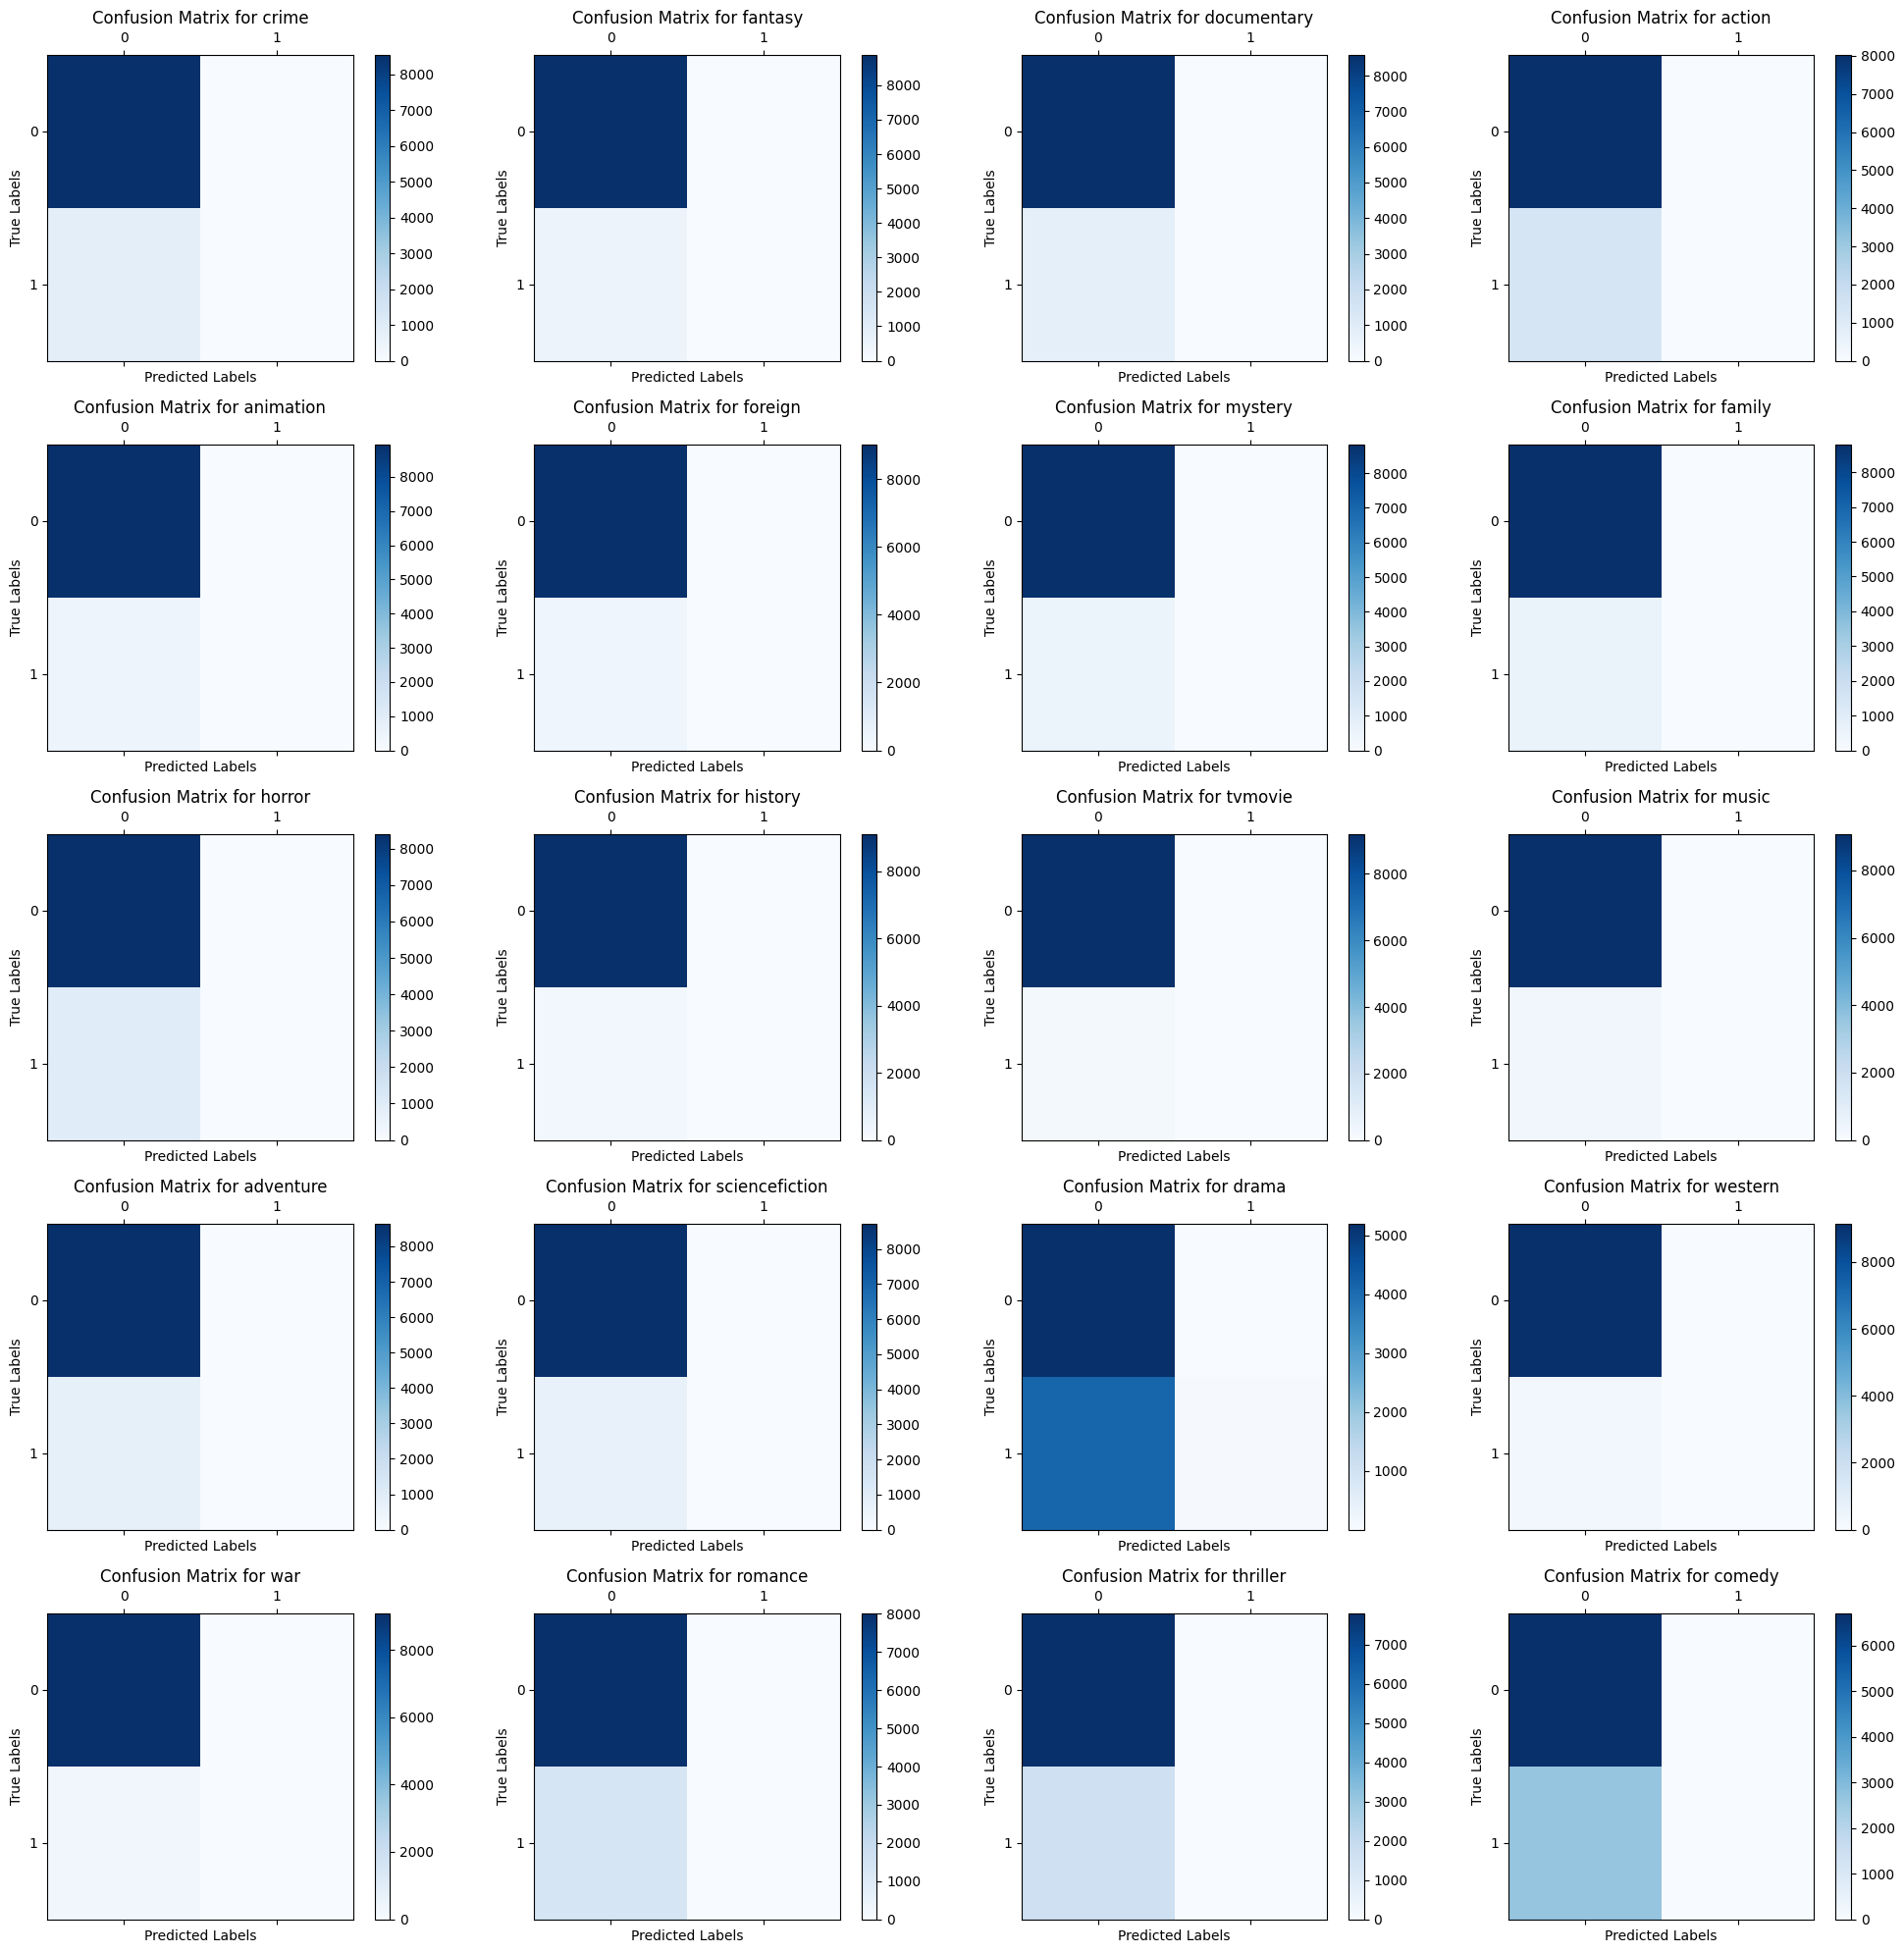

In [ ]:
#Used Random forest values to create confusion matrix for each genre
import matplotlib.pyplot as plt
import numpy as np
from pyspark.ml.classification import RandomForestClassifier
from pyspark.sql.functions import col
from pyspark.mllib.evaluation import MulticlassMetrics

# Initialize subplot grid
fig, axes = plt.subplots(5, 4, figsize=(20, 20))  # 5 rows and 4 columns for 20 genres
axes = axes.flatten()  # flatten the axes array for easy iteration

# Loop over the genres and plot confusion matrices
for i, genre in enumerate(genre_list):
    # Prepare data with this genre as the label
    data = df.select("features", col(genre).alias("label"))

    train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

    # Train model
    rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=20, maxBins=128)
    model = rf.fit(train_data)
    predictions = model.transform(test_data)

    # Extract predicted and actual labels with correct data types
    prediction_and_labels = predictions.selectExpr(
        "cast(prediction as double) as prediction",
        "cast(label as double) as label"
    ).rdd.map(lambda row: (row['prediction'], row['label']))

    # Created the confusion matrix
    metrics = MulticlassMetrics(prediction_and_labels)
    confusion_matrix = metrics.confusionMatrix().toArray()

    # Plotted the confusion matrix on the appropriate subplot
    ax = axes[i]
    cax = ax.matshow(confusion_matrix, cmap="Blues")
    fig.colorbar(cax, ax=ax)
    ax.set_title(f"Confusion Matrix for {genre}")
    ax.set_xlabel("Predicted Labels")
    ax.set_ylabel("True Labels")

    # Set ticks for 0 and 1 labels
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])

plt.tight_layout()  # Adjust layout for better spacing
plt.show()


/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  w

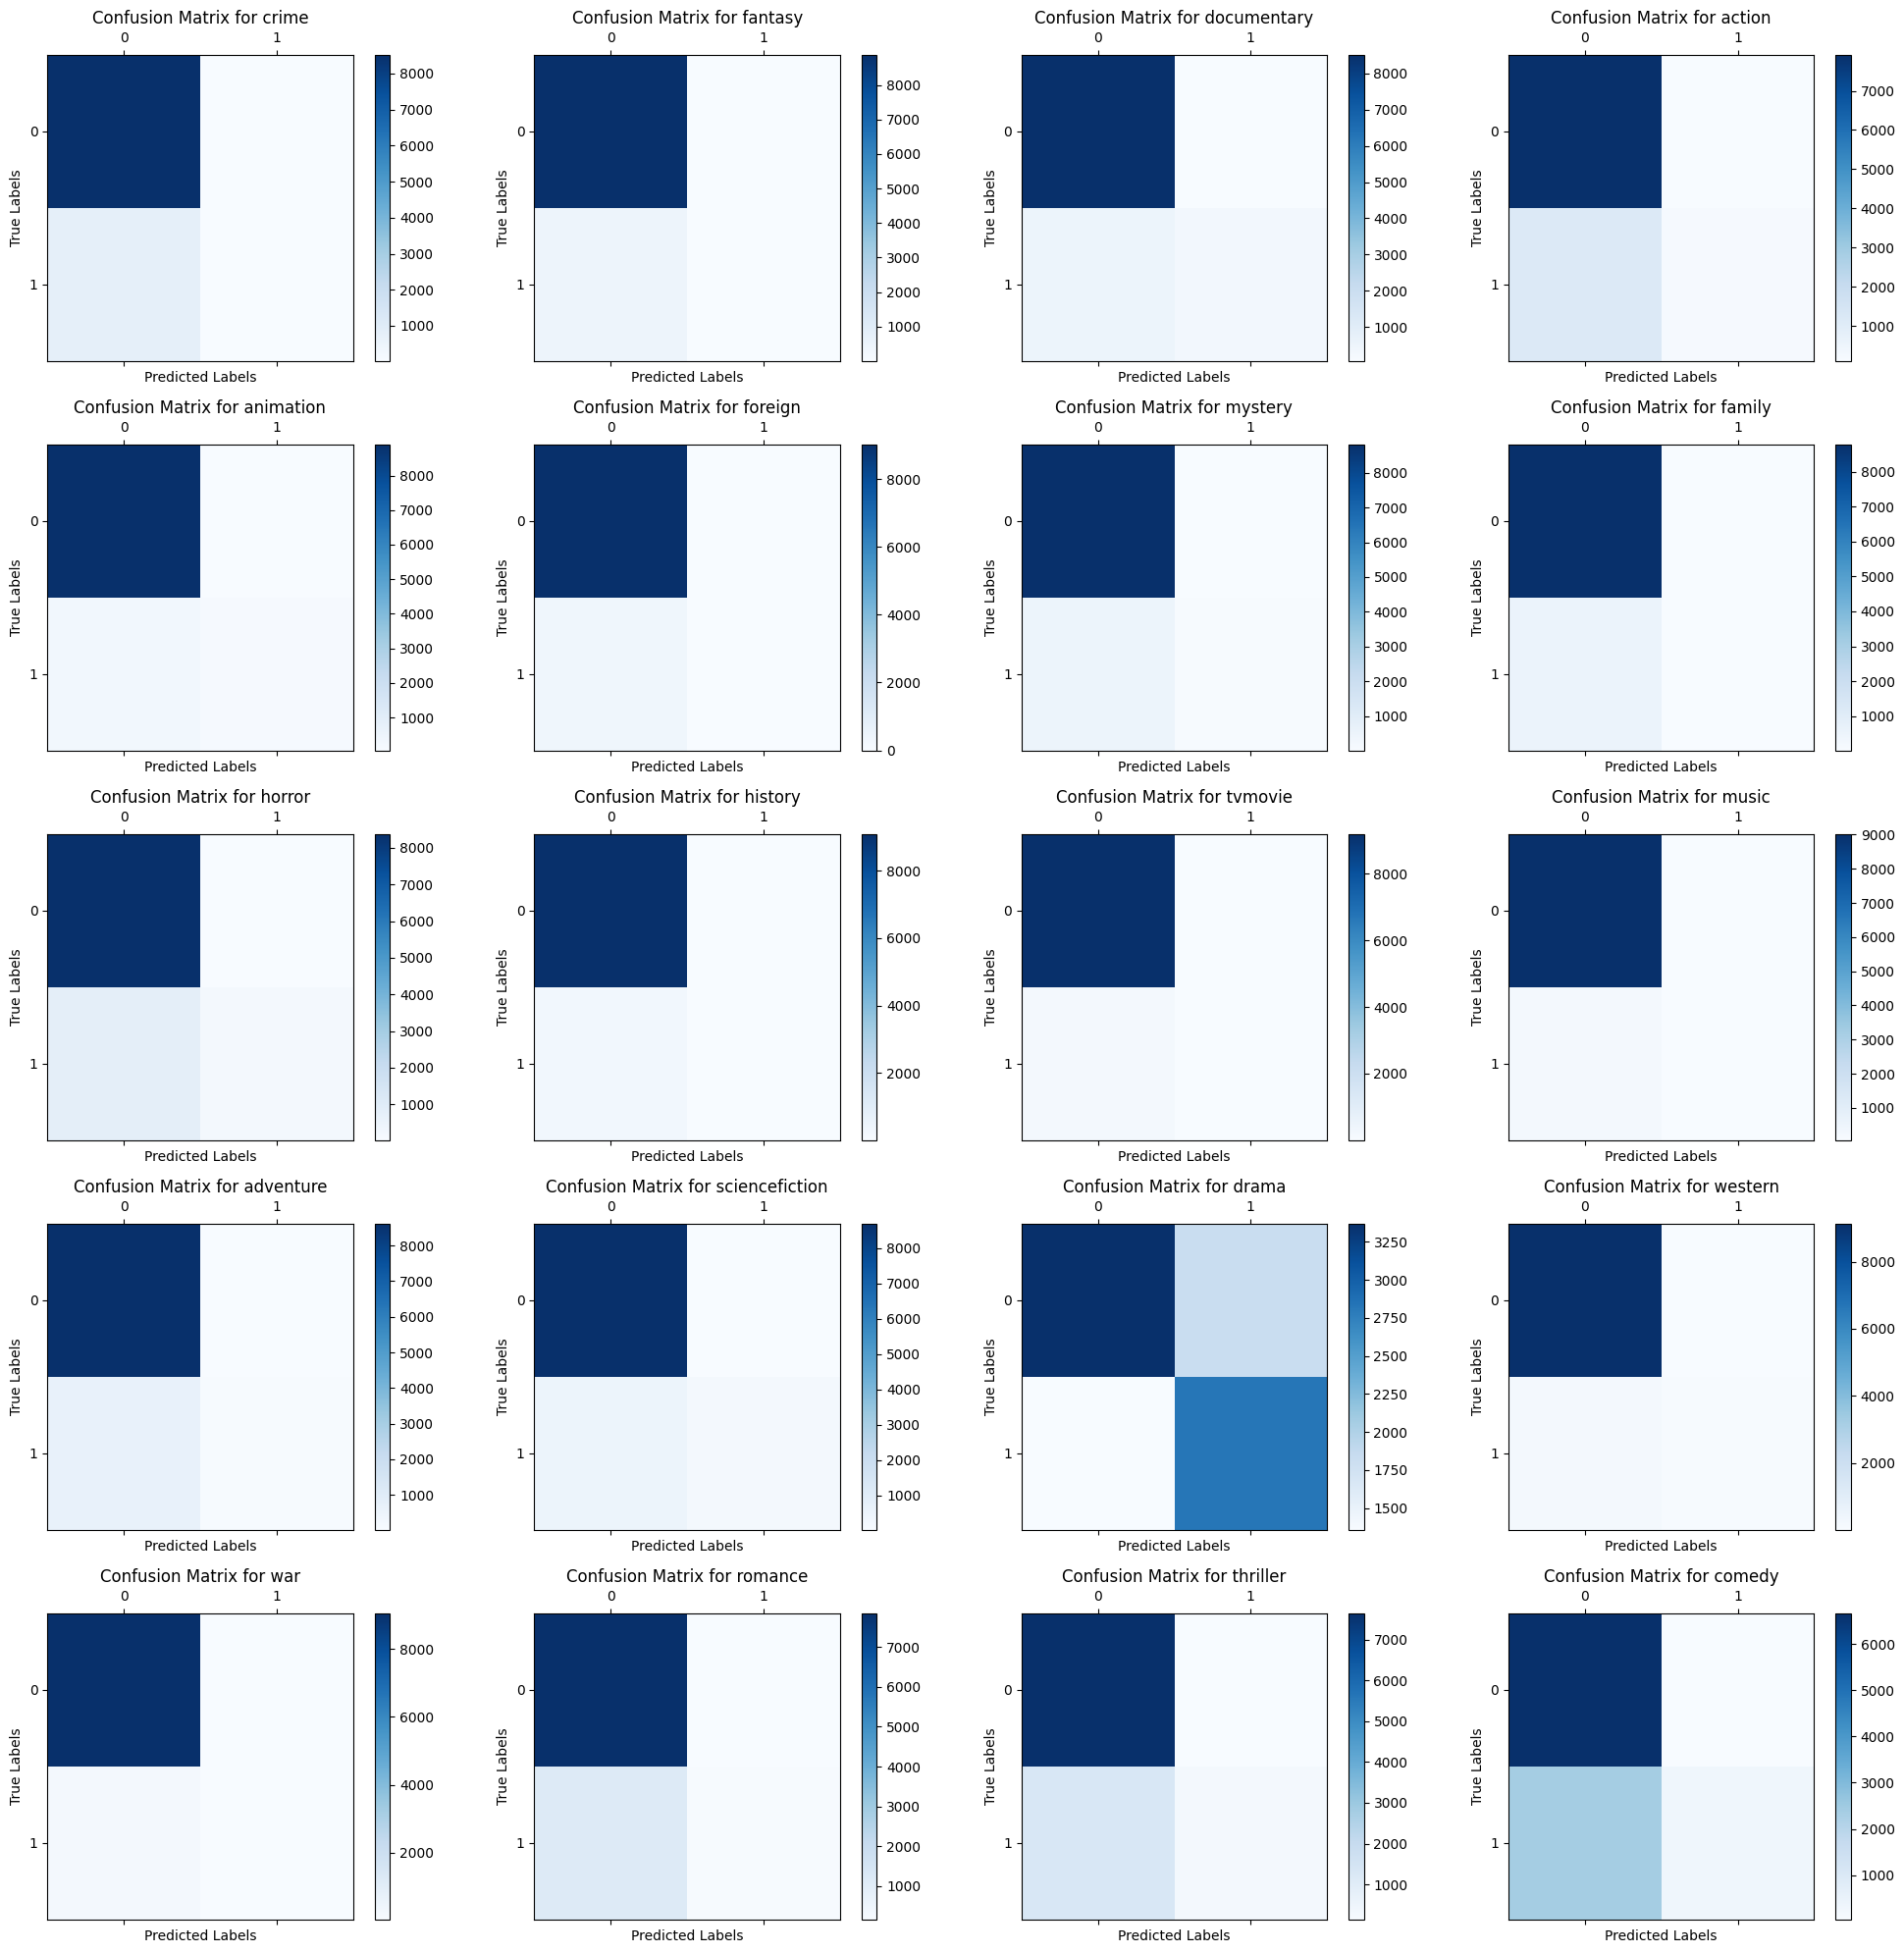

In [ ]:
# Used Decision Tree values to create confusion matrix for each genre
import matplotlib.pyplot as plt
import numpy as np
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.sql.functions import col
from pyspark.mllib.evaluation import MulticlassMetrics

# Initialize subplot grid
fig, axes = plt.subplots(5, 4, figsize=(20, 20))  # 5 rows and 4 columns for 20 genres
axes = axes.flatten()  # flatten the axes array for easy iteration

# Loop over the genres and plot confusion matrices
for i, genre in enumerate(genre_list):
    # Prepare data with this genre as the label
    data = df.select("features", col(genre).alias("label"))

    train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

    # Train Decision Tree model
    dt = DecisionTreeClassifier(labelCol="label", featuresCol="features", maxBins=128)
    model = dt.fit(train_data)
    predictions = model.transform(test_data)

    # Extract predicted and actual labels with correct data types
    prediction_and_labels = predictions.selectExpr(
        "cast(prediction as double) as prediction",
        "cast(label as double) as label"
    ).rdd.map(lambda row: (row['prediction'], row['label']))

    # Create the confusion matrix
    metrics = MulticlassMetrics(prediction_and_labels)
    confusion_matrix = metrics.confusionMatrix().toArray()

    # Plot the confusion matrix on the appropriate subplot
    ax = axes[i]
    cax = ax.matshow(confusion_matrix, cmap="Blues")
    fig.colorbar(cax, ax=ax)
    ax.set_title(f"Confusion Matrix for {genre}")
    ax.set_xlabel("Predicted Labels")
    ax.set_ylabel("True Labels")

    # Set ticks for 0 and 1 labels
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])

plt.tight_layout()  # Adjust layout for better spacing
plt.show()


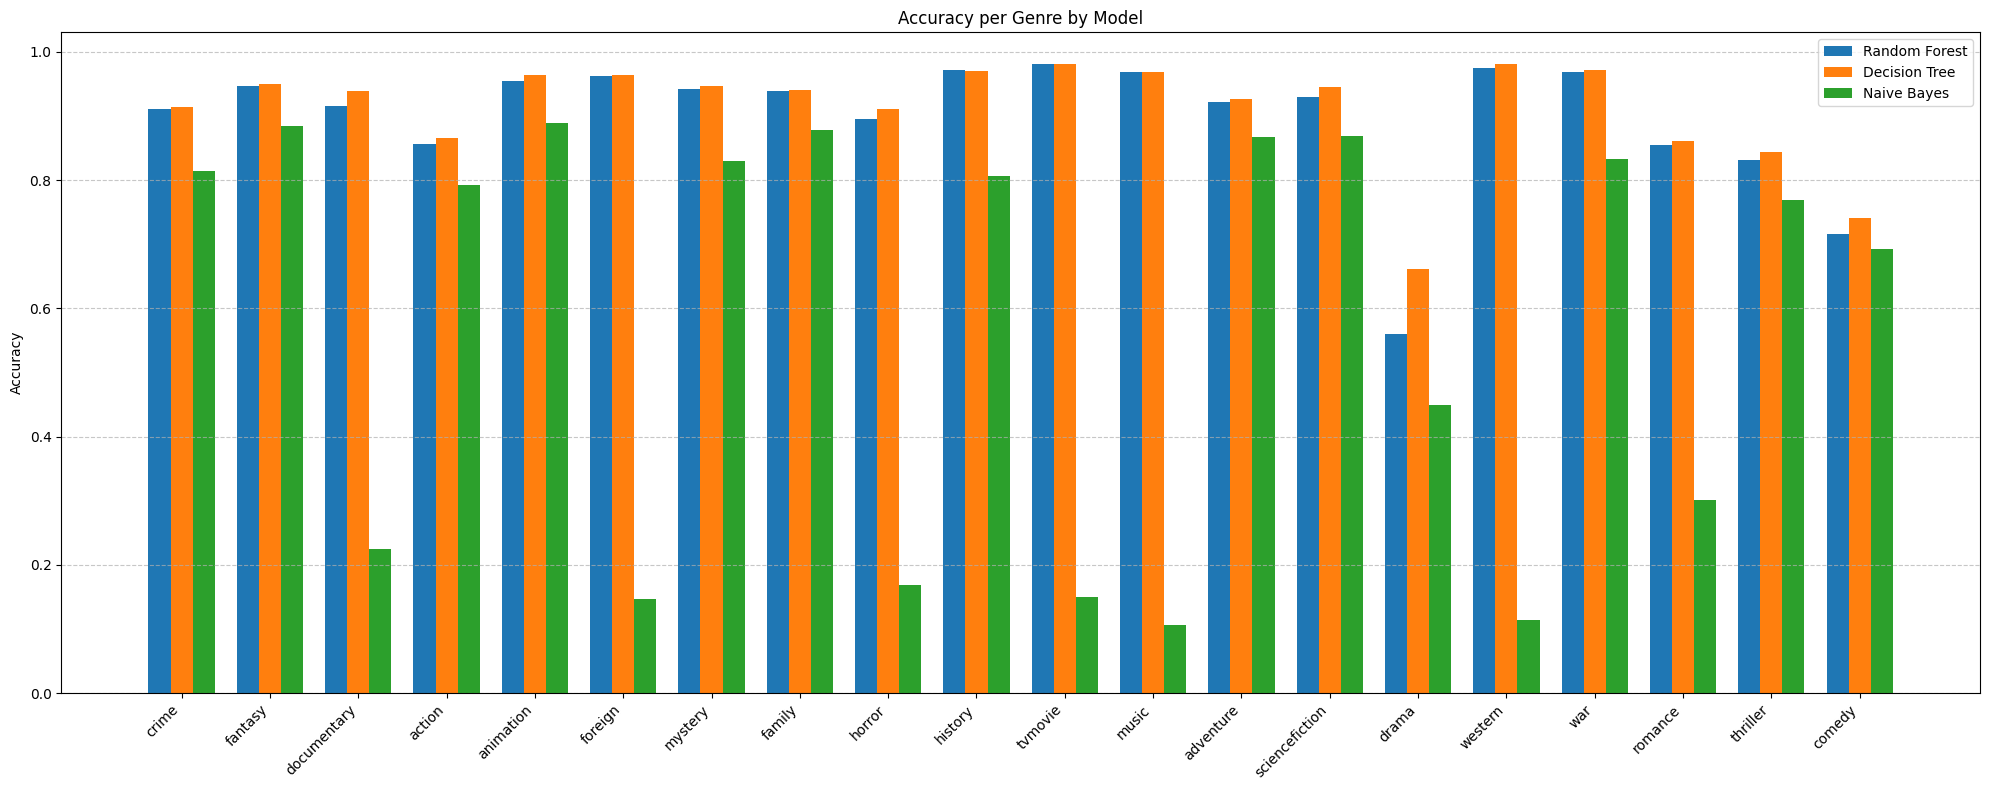

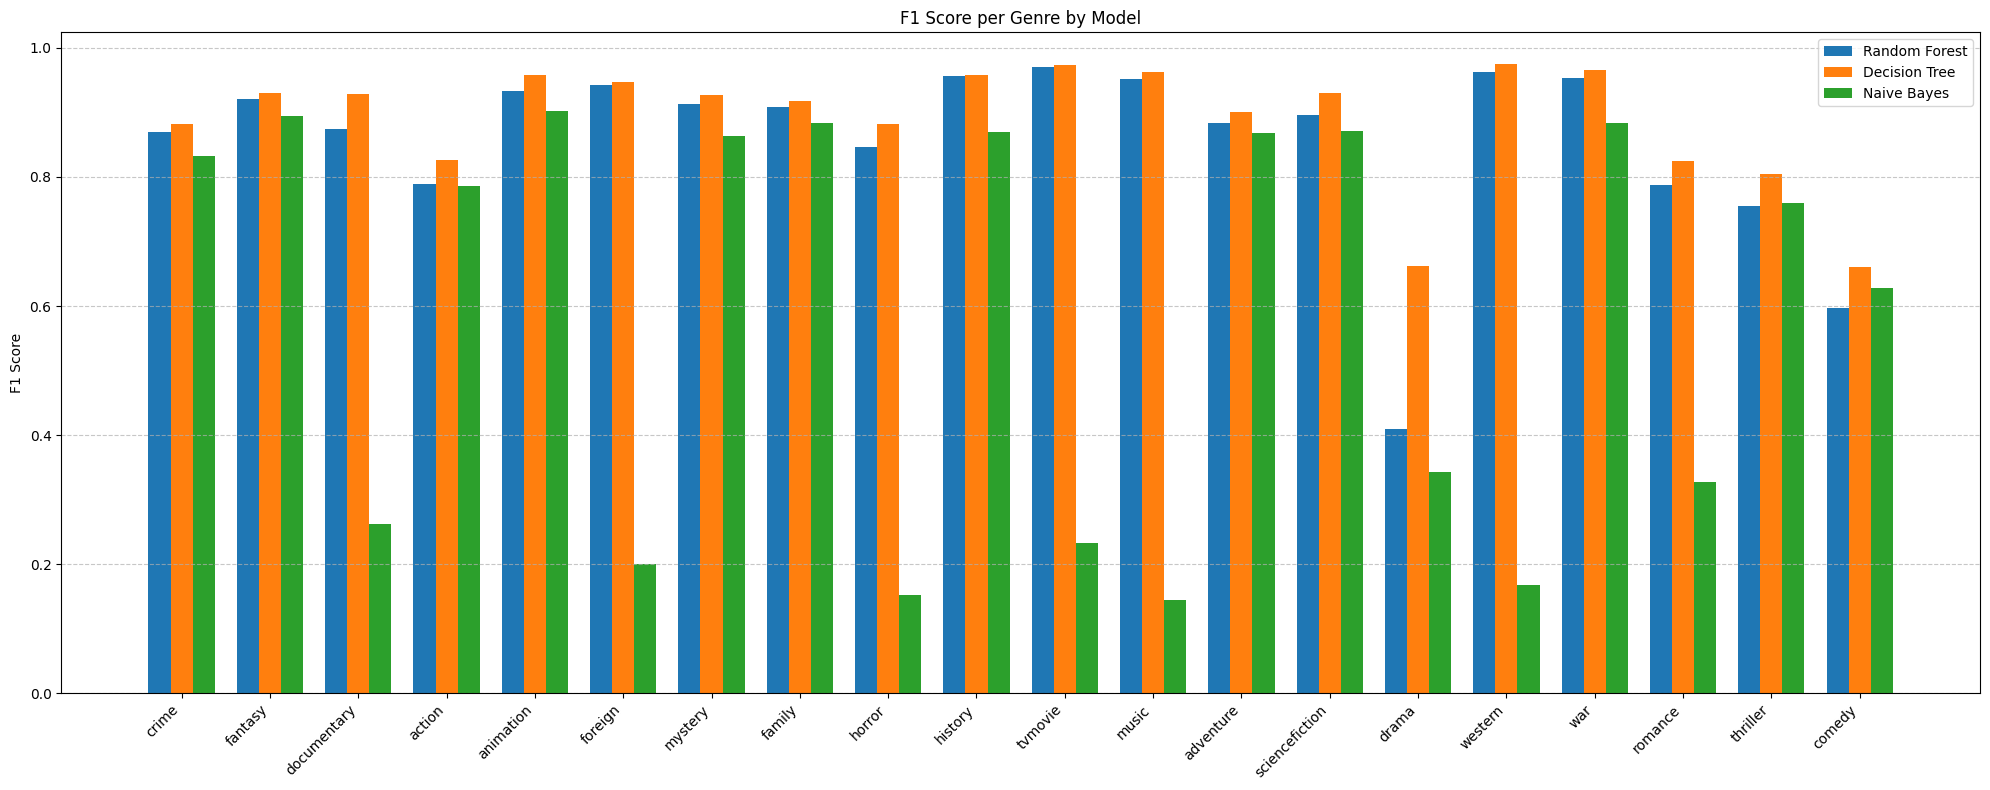

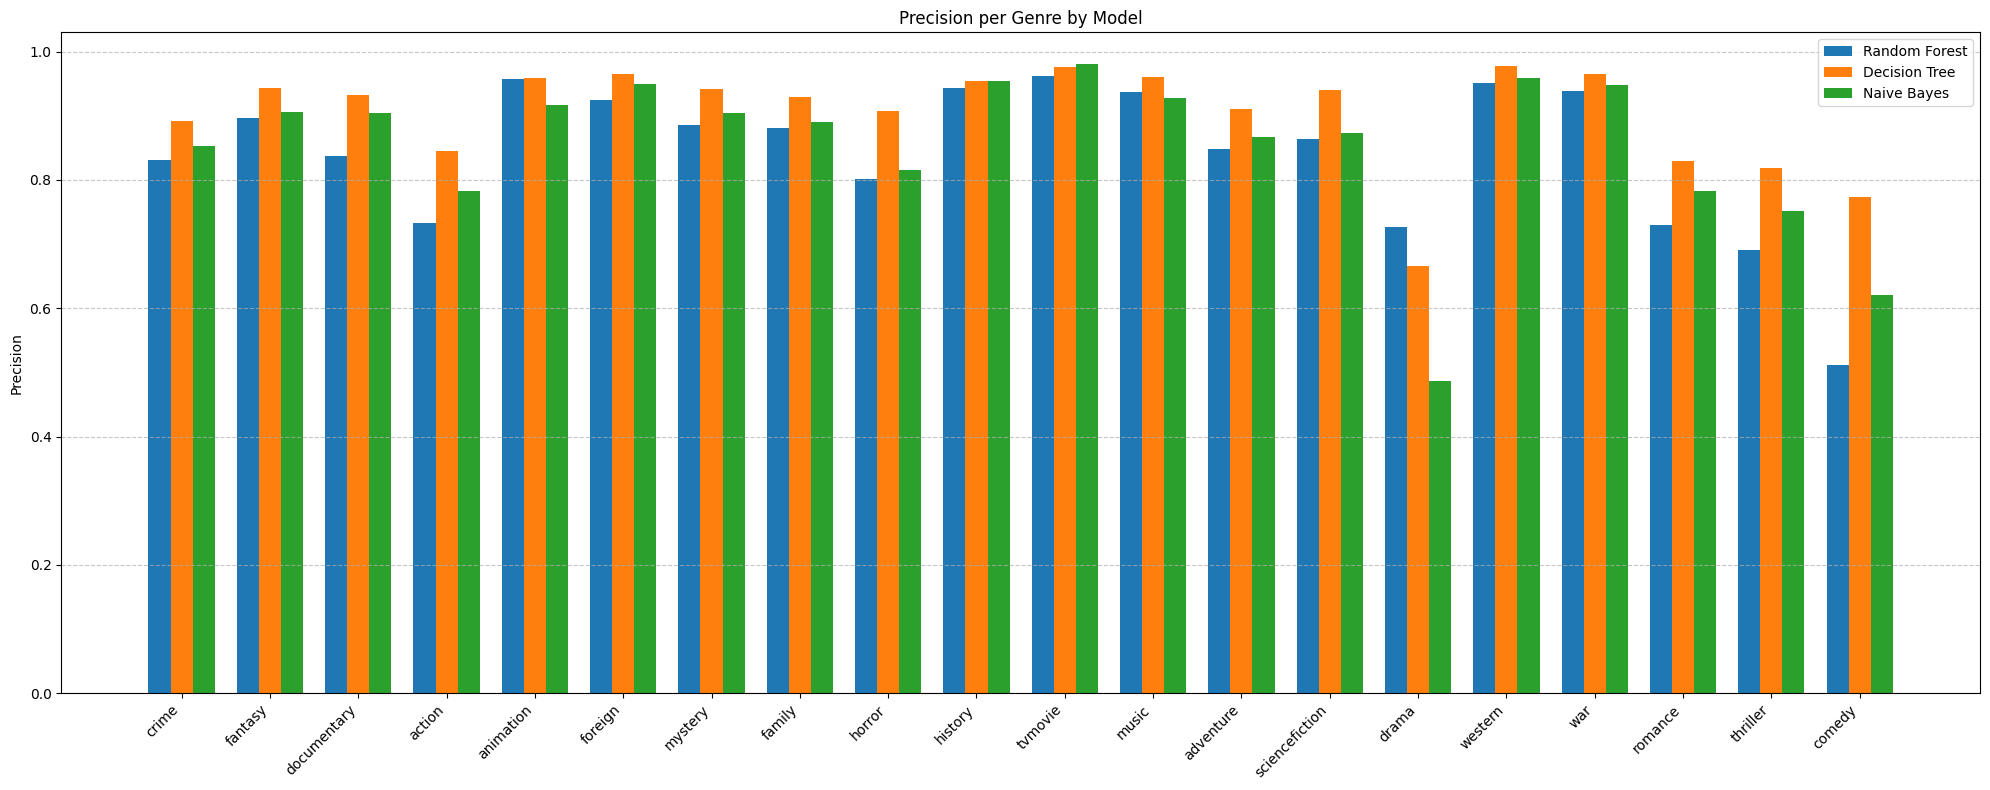

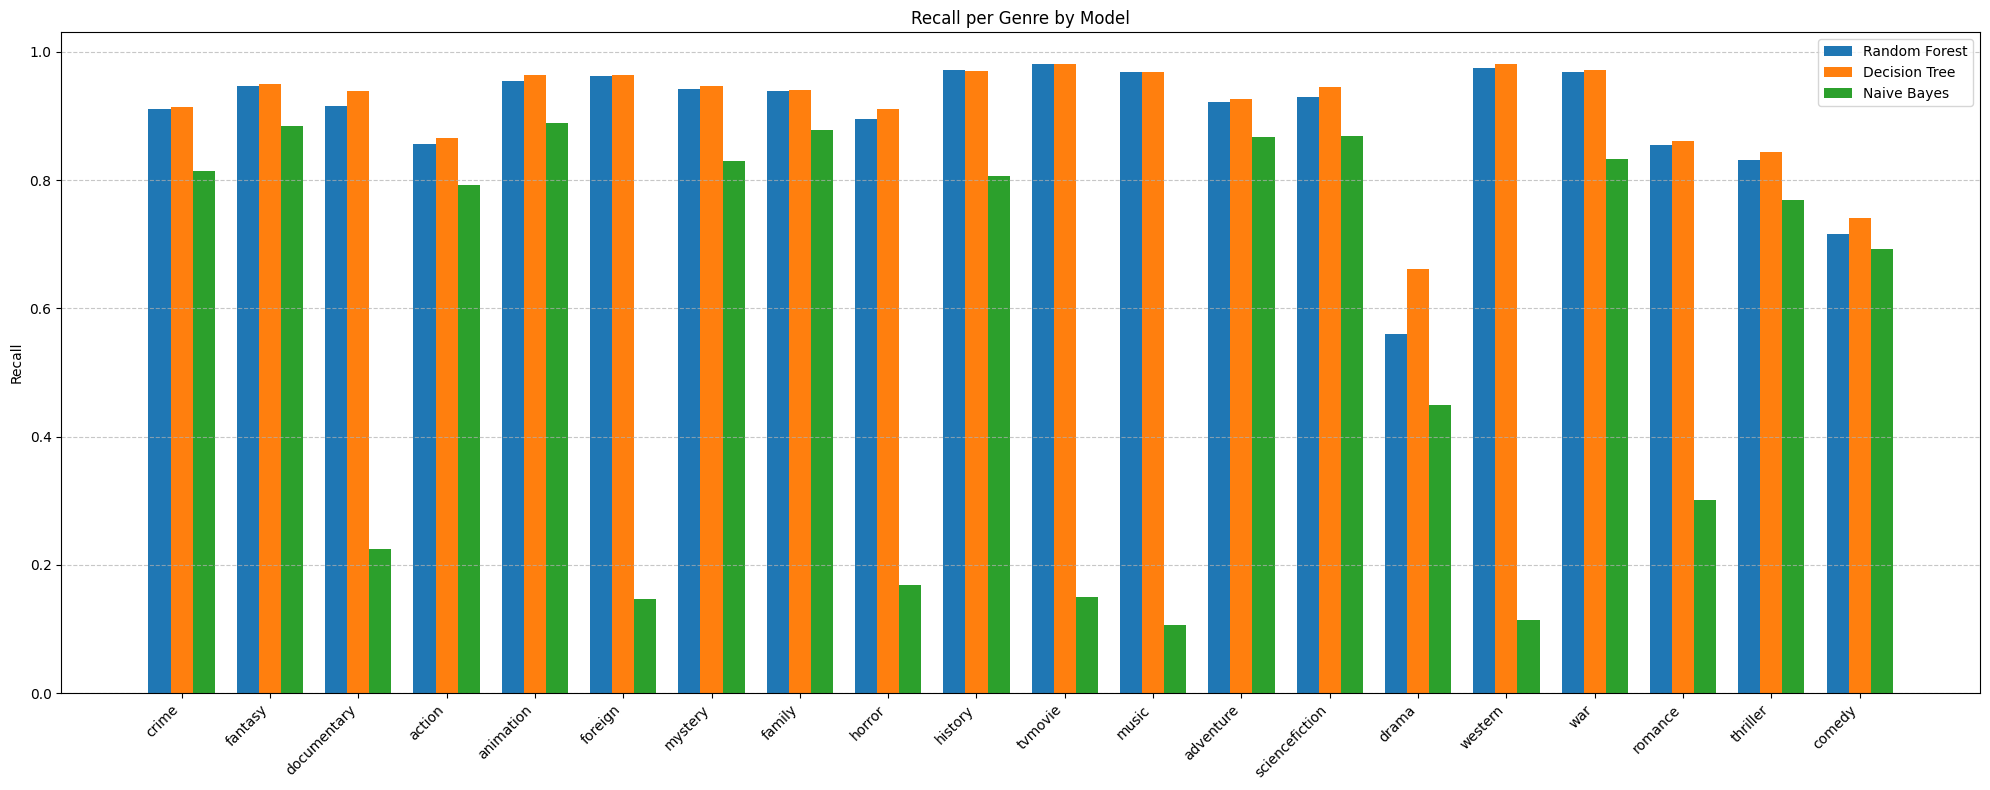

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Genre labels
genres = [
    "crime", "fantasy", "documentary", "action", "animation", "foreign", "mystery", "family", "horror",
    "history", "tvmovie", "music", "adventure", "sciencefiction", "drama", "western", "war", "romance",
    "thriller", "comedy"
]

# Metrics for each model
metrics = {
    "Random Forest": {
        "Accuracy": [0.9114, 0.9471, 0.9151, 0.8560, 0.9547, 0.9615, 0.9413, 0.9382, 0.8956,
                     0.9713, 0.9806, 0.9678, 0.9213, 0.9295, 0.5601, 0.9749, 0.9687, 0.8546, 0.8310, 0.7155],
        "F1 Score": [0.8691, 0.9214, 0.8745, 0.7896, 0.9333, 0.9426, 0.9129, 0.9083, 0.8462,
                     0.9572, 0.9710, 0.9519, 0.8835, 0.8955, 0.4091, 0.9626, 0.9534, 0.7876, 0.7543, 0.5968],
        "Precision": [0.8306, 0.8970, 0.8374, 0.7327, 0.9567, 0.9245, 0.8861, 0.8803, 0.8020,
                      0.9434, 0.9615, 0.9366, 0.8487, 0.8639, 0.7269, 0.9505, 0.9385, 0.7303, 0.6906, 0.5119],
        "Recall": [0.9114, 0.9471, 0.9151, 0.8560, 0.9547, 0.9615, 0.9413, 0.9382, 0.8956,
                   0.9713, 0.9806, 0.9678, 0.9213, 0.9295, 0.5601, 0.9749, 0.9687, 0.8546, 0.8310, 0.7155],
    },
    "Decision Tree": {
        "Accuracy": [0.9141, 0.9504, 0.9390, 0.8663, 0.9640, 0.9637, 0.9470, 0.9412, 0.9102,
                     0.9702, 0.9813, 0.9685, 0.9260, 0.9447, 0.6608, 0.9803, 0.9719, 0.8606, 0.8444, 0.7415],
        "F1 Score": [0.8815, 0.9308, 0.9284, 0.8258, 0.9573, 0.9479, 0.9278, 0.9182, 0.8816,
                     0.9584, 0.9737, 0.9624, 0.9001, 0.9308, 0.6618, 0.9754, 0.9652, 0.8255, 0.8043, 0.6603],
        "Precision": [0.8924, 0.9434, 0.9327, 0.8444, 0.9585, 0.9650, 0.9413, 0.9296, 0.9067,
                      0.9535, 0.9765, 0.9603, 0.9103, 0.9401, 0.6661, 0.9776, 0.9652, 0.8292, 0.8191, 0.7729],
        "Recall": [0.9141, 0.9504, 0.9390, 0.8663, 0.9640, 0.9637, 0.9470, 0.9412, 0.9102,
                   0.9702, 0.9813, 0.9685, 0.9260, 0.9447, 0.6608, 0.9803, 0.9719, 0.8606, 0.8444, 0.7415],
    },
    "Naive Bayes": {
        "Accuracy": [0.8144, 0.8850, 0.2254, 0.7917, 0.8896, 0.1467, 0.8305, 0.8779, 0.1686,
                     0.8063, 0.1506, 0.1055, 0.8677, 0.8683, 0.4495, 0.1143, 0.8327, 0.3019, 0.7691, 0.6928],
        "F1 Score": [0.8320, 0.8950, 0.2623, 0.7867, 0.9024, 0.1997, 0.8629, 0.8841, 0.1522,
                     0.8690, 0.2323, 0.1436, 0.8676, 0.8710, 0.3425, 0.1671, 0.8830, 0.3271, 0.7598, 0.6283],
        "Precision": [0.8526, 0.9057, 0.9039, 0.7820, 0.9162, 0.9502, 0.9045, 0.8907, 0.8161,
                      0.9543, 0.9810, 0.9276, 0.8676, 0.8738, 0.4863, 0.9587, 0.9483, 0.7834, 0.7517, 0.6212],
        "Recall": [0.8144, 0.8850, 0.2254, 0.7917, 0.8896, 0.1467, 0.8305, 0.8779, 0.1686,
                   0.8063, 0.1506, 0.1055, 0.8677, 0.8683, 0.4495, 0.1143, 0.8327, 0.3019, 0.7691, 0.6928],
    }
}

# Function to plot grouped bar chart for a metric
def plot_metric(metric_name):
    x = np.arange(len(genres))  # the label locations
    width = 0.25  # width of the bars

    fig, ax = plt.subplots(figsize=(20, 8))

    for i, (model_name, model_data) in enumerate(metrics.items()):
        ax.bar(x + i * width, model_data[metric_name], width, label=model_name)

    ax.set_ylabel(metric_name)
    ax.set_title(f'{metric_name} per Genre by Model')
    ax.set_xticks(x + width)
    ax.set_xticklabels(genres, rotation=45, ha="right")
    ax.legend()

    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

# Plot all the four metrics
plot_metric("Accuracy")
plot_metric("F1 Score")
plot_metric("Precision")
plot_metric("Recall")
